In [ ]:
# %% Imports
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# %% Data
# area: (distance_to_bgc_km, distance_to_station_km, major_roads, actual_listings)
data = {
    "Ugong":          (7.94, 1.56, 4, 260),
    "Ortigas CBD":    (7.20, 0.55, 4, 150),
    "Oranbo":         (6.82, 1.45, 3, 140),
    "San Antonio":    (7.20, 0.77, 3, 120),
    "Highway Hills":  (6.28, 0.36, 3, 72),
    "Cupang":         (10.39, 5.15, 3, 35),
    "San Agustin I":  (26.46, 14.67, 2, 20),
    "Paligsahan":     (11.58, 2.17, 3, 18),
    "Novaliches":     (21.45, 9.46, 3, 17),
    "Bagumbayan":     (10.42, 1.97, 3, 15),
}

areas = list(data.keys())
bgc_dist     = np.array([v[0] for v in data.values()])
station_dist = np.array([v[1] for v in data.values()])
roads        = np.array([v[2] for v in data.values()])
listings     = np.array([v[3] for v in data.values()])

In [ ]:
# %% Helper function: scatter plot with trend line
def plot_correlation(x, y, labels, xlabel, title, color, x_pad=0.5):
    r = np.corrcoef(x, y)[0, 1]
    slope, intercept = np.polyfit(x, y, 1)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(x, y, color=color, s=90, zorder=3, edgecolor="white", linewidth=0.8)

    for xi, yi, label in zip(x, y, labels):
        ax.annotate(label, (xi, yi), textcoords="offset points",
                    xytext=(6, 4), fontsize=8, color="#444444")

    x_line = np.linspace(x.min() - x_pad, x.max() + x_pad, 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, linestyle="--", color="#888888", linewidth=2,
             label=f"Trend line (r = {r:.2f})")

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Actual Listings", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25)
    fig.tight_layout()
    plt.show()

    print(f"r = {r:.3f}, slope = {slope:.2f}, intercept = {intercept:.2f}")

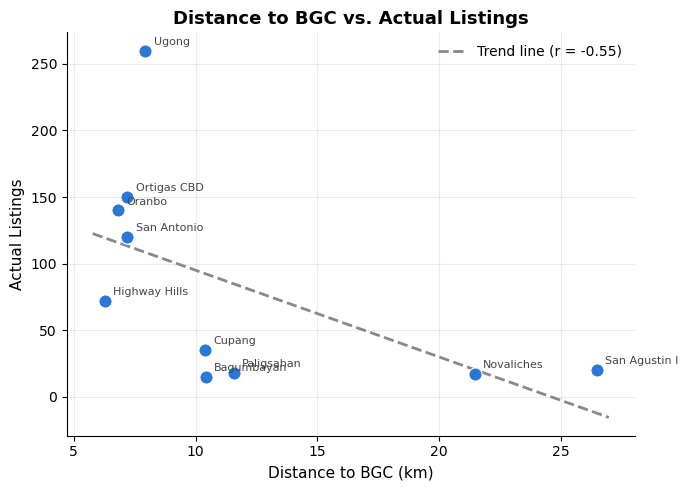

r = -0.548, slope = -6.52, intercept = 160.20


In [ ]:
# %% Graph 1: Distance to BGC vs. Listings
plot_correlation(
    bgc_dist, listings, areas,
    xlabel="Distance to BGC (km)",
    title="Distance to BGC vs. Actual Listings",
    color="#2a78d6",
)

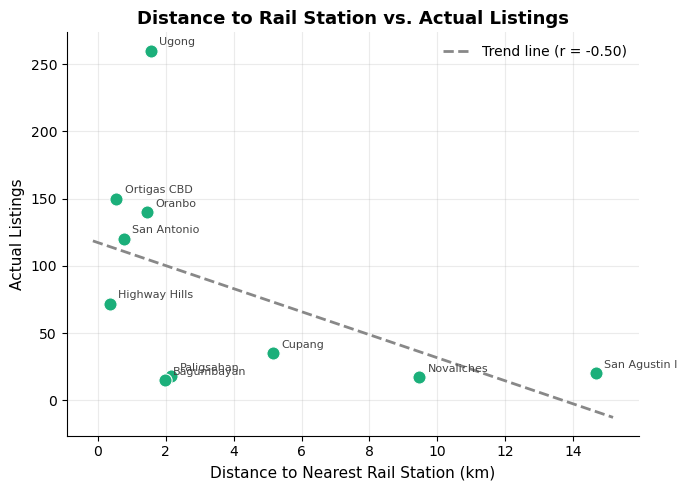

r = -0.495, slope = -8.57, intercept = 117.36


In [ ]:
# %% Graph 2: Distance to Rail Station vs. Listings
plot_correlation(
    station_dist, listings, areas,
    xlabel="Distance to Nearest Rail Station (km)",
    title="Distance to Rail Station vs. Actual Listings",
    color="#1baf7a",
)

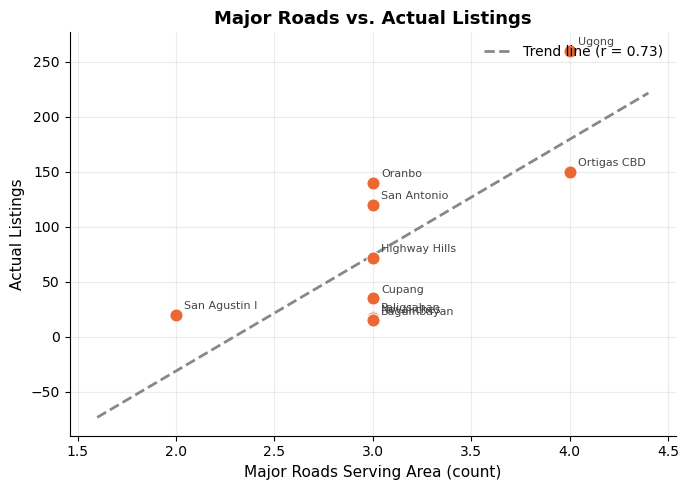

r = 0.732, slope = 105.28, intercept = -241.66


In [ ]:
# %% Graph 3: Major Roads vs. Listings
plot_correlation(
    roads, listings, areas,
    xlabel="Major Roads Serving Area (count)",
    title="Major Roads vs. Actual Listings",
    color="#eb6834",
    x_pad=0.4,
)